In [8]:
import os
import pandas as pd
import xarray as xr
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns
import re 
from sklearn.metrics import balanced_accuracy_score
import pickle
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import torch
import matplotlib.pyplot as plt
from torchvision import transforms, utils
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn                  
import torch.nn.functional as F      
import shap

import sys
# Add the path to the 'src' directory (or the root directory of your package)
sys.path.append('..') 

import machine_learning
from machine_learning.custom_datasets import SPEI_extremes_location_dataset
from machine_learning import convnext_functions 


### Counts HW per year 

Doing site: cordoba
Mean counts 1950-2000 for cordoba is : 10.333333333333334
Doing site: lyon
Mean counts 1950-2000 for lyon is : 9.958333333333334
Doing site: hannover
Mean counts 1950-2000 for hannover is : 10.270833333333334
Doing site: stockholm
Mean counts 1950-2000 for stockholm is : 10.208333333333334
Doing site: belgrado
Mean counts 1950-2000 for belgrado is : 10.395833333333334
Doing site: marrakech
Mean counts 1950-2000 for marrakech is : 9.9375


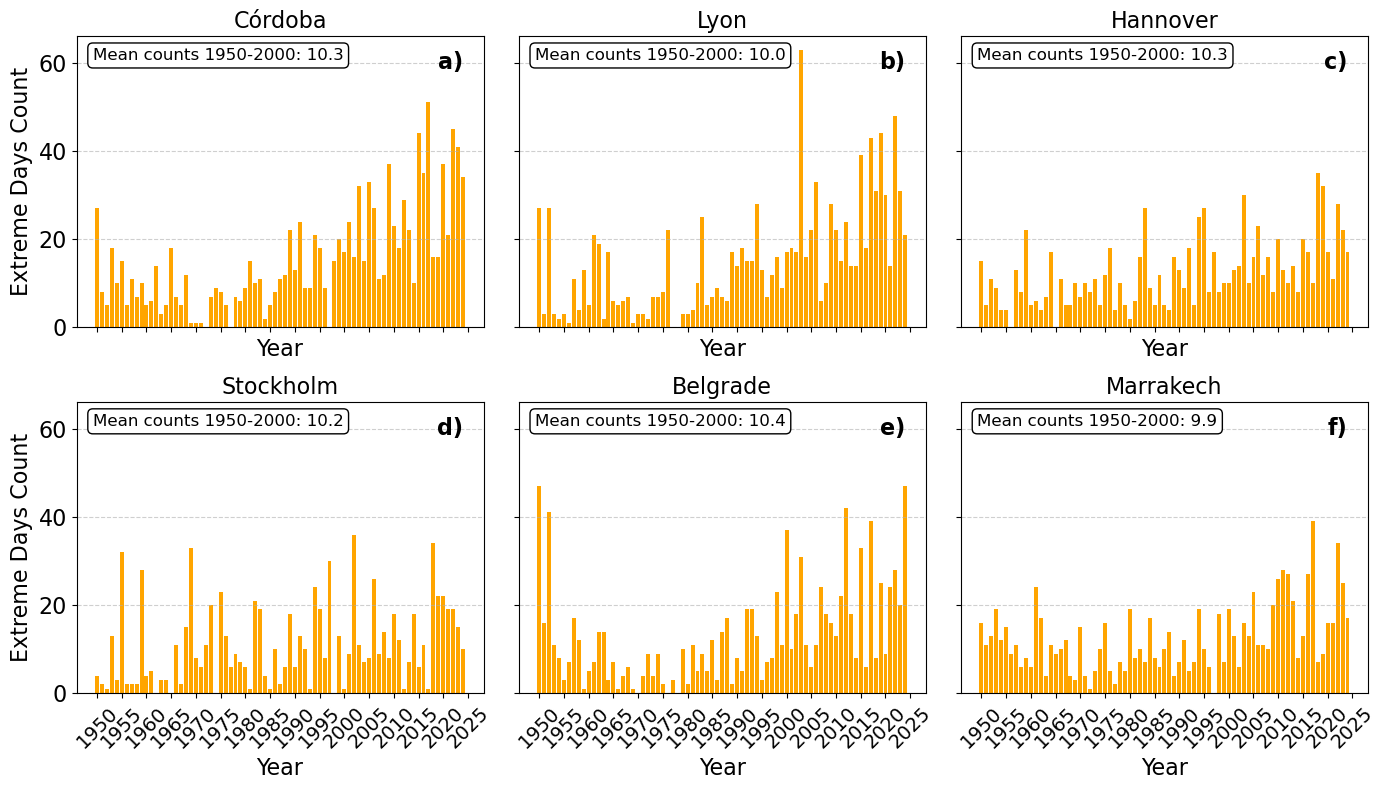

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import matplotlib.ticker as ticker

sites = ['cordoba', 'lyon', 'hannover', 'stockholm', 'belgrado', 'marrakech']
sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade', 'Marrakech']

# Create subplots with shared axes
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey='row', sharex='col')
axes = axes.flatten()

date_range = pd.date_range(start='1950-01-01', end='2024-12-31', freq='D')
filtered_dates = np.array([
    d for d in date_range 
    if d.month in [6, 7, 8] and not (d.year == 2024 and d.month == 7 and d.day == 31)
])

file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"

variables = ['swvl1','swvl2','swvl3'] 

for i, site in enumerate(sites): 
    print(f"Doing site: {site}")

    dataset = machine_learning.LocalScale_Dataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/data/era5_land/lagged_anomalies_and_event_detection/90p_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", 
                                                                                                start_date="1950-01-03", 
                                                                                                end_date="2024-12-31", 
                                                                                                months=[6,7,8],
                                                                                                file_CO2=file_CO2,
                                                                                                variables=variables,)
    
    
    y_true = dataset.labels
    
    df = pd.DataFrame({
        'date': filtered_dates,
        'label': y_true
    })
    df['year'] = pd.DatetimeIndex(df['date']).year
    counts = df[df['label'] == 1].groupby('year').size()
    counts = counts.groupby(counts.index).sum()  
    counts = counts.sort_index()
    counts.index = counts.index.astype(int)
    mean_counts = np.mean(counts[:48])
    print(f"Mean counts 1950-2000 for {site} is : {mean_counts}")
    
    ax = axes[i]
    ax.clear()
    #counts.plot(kind='bar', ax=ax, color='orange')
    ax.bar(counts.index, counts.values, color='orange', width=0.8)

    ax.set_title(sites_title[i],fontsize=16)
    ax.set_xlabel('Year', fontsize=16)

    ax.text(0.95, 0.95, f'{chr(97+i)})',  # 97 is ASCII for 'a'
            transform=ax.transAxes,
            fontsize=16,
            fontweight='bold',
            va='top',
            ha='right')
    
    # Only set ylabel for leftmost plots
    if i % 3 == 0:
        ax.set_ylabel('Extreme Days Count', fontsize=16)
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))  # every 5 years
    ax.tick_params(axis='x', labelsize=14)
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
    
    ax.tick_params(axis='y', labelsize=16)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    ax.text(0.04, 0.96,
               f"Mean counts 1950-2000: {mean_counts:.1f}",
               transform=ax.transAxes,
               fontsize=12,
               verticalalignment='top',
               bbox=dict(boxstyle="round", facecolor="white"))

    ax.set_ylim(0,66)


#plt.suptitle("Yearly Extreme Count of the different Locations",fontsize=15)
plt.tight_layout()
#plt.savefig("/home/bsc/bsc167965/TFM/input_data/arnau-tfm/plots/90p_yearly_counts_extremes_locations.pdf")
plt.show()

## Count per year comparison

Doing site: cordoba
Doing site: lyon


KeyboardInterrupt: 

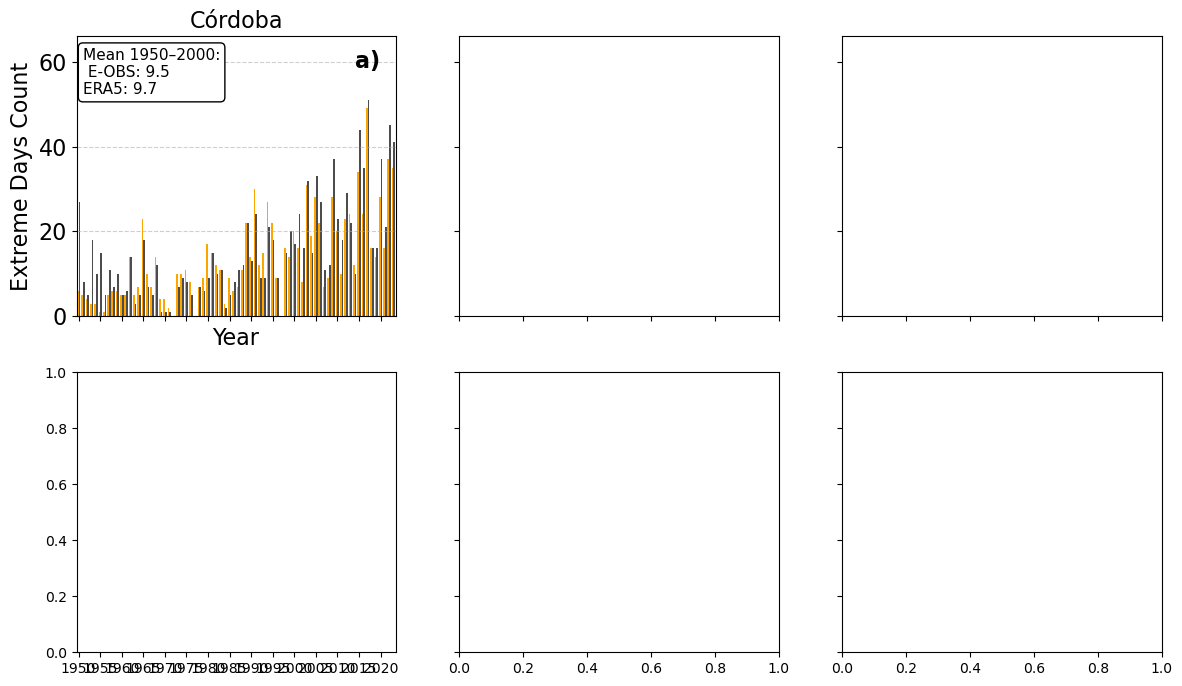

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import matplotlib.ticker as ticker

sites = ['cordoba', 'lyon', 'hannover', 'stockholm', 'belgrado', 'marrakech']
sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade', 'Marrakech']

# Create subplots with shared axes
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey='row', sharex='col')
axes = axes.flatten()

date_range = pd.date_range(start='1950-01-01', end='2023-12-31', freq='D')
filtered_dates = np.array([
    d for d in date_range 
    if d.month in [6, 7, 8] and not (d.year == 2024 and d.month == 7 and d.day == 31)
])

# Define common years range
common_years = range(1950, 2024)  # 1950 to 2023 inclusive

bar_width = 0.4

for i, site in enumerate(sites): 
    print(f"Doing site: {site}")

    dataset = machine_learning.LocalScale_Dataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/data/era5_land/obs_lagged_anomalies_and_event_detection/obs_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", 
                                                                                                start_date="1950-01-03", 
                                                                                                end_date="2023-12-31", 
                                                                                                months=[6,7,8],
                                                                                                file_CO2=file_CO2,
                                                                                                variables=variables,)
    
    y_true = dataset.labels
    df = pd.DataFrame({'date': filtered_dates, 'label': y_true})
    df['year'] = df['date'].dt.year
    counts_obs = df[df['label'] == 1].groupby('year').size()

    dataset_alt = machine_learning.LocalScale_Dataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/data/era5_land/lagged_anomalies_and_event_detection/90p_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", 
                                                                                                start_date="1950-01-03", 
                                                                                                end_date="2023-12-31", 
                                                                                                months=[6,7,8],
                                                                                                file_CO2=file_CO2,
                                                                                                variables=variables,)
    
    y_true_alt = dataset_alt.labels
    df_alt = pd.DataFrame({'date': filtered_dates, 'label': y_true_alt})
    df_alt['year'] = df_alt['date'].dt.year
    counts_alt = df_alt[df_alt['label'] == 1].groupby('year').size()

    # Reindex both datasets to the common years range, filling missing years with 0
    counts_obs = counts_obs.reindex(common_years, fill_value=0)
    counts_alt = counts_alt.reindex(common_years, fill_value=0)

    mean_counts_obs = np.mean(counts_obs.loc[1950:2000])
    mean_counts_alt = np.mean(counts_alt.loc[1950:2000])

    # Plot
    ax = axes[i]
    ax.clear()

    x = np.arange(len(common_years))
    ax.bar(x - bar_width/2, counts_obs.values, width=bar_width, color='orange', label='obs.')
    ax.bar(x + bar_width/2, counts_alt.values, width=bar_width, color='black', alpha=0.7, label='ERA5')

    ax.set_title(sites_title[i], fontsize=16)
    ax.set_xlabel('Year', fontsize=16)
    
    # Set consistent x-axis ticks for all subplots
    tick_positions = np.arange(0, len(common_years), 5)  # Every 5 years
    tick_labels = [str(year) for year in common_years[::5]]
    
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, fontsize=15)

    if i % 3 == 0:
        ax.set_ylabel('Extreme Days Count', fontsize=16)
    
    ax.tick_params(axis='y', labelsize=16)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_ylim(0, 66)
    
    # Set consistent x-axis limits for all subplots
    ax.set_xlim(-0.5, len(common_years) - 0.5)

    ax.text(0.95, 0.95, f'{chr(97+i)})',
            transform=ax.transAxes,
            fontsize=16,
            fontweight='bold',
            va='top',
            ha='right')
    
    ax.text(0.02, 0.96,
            f"Mean 1950–2000:\n E-OBS: {mean_counts_obs:.1f}\nERA5: {mean_counts_alt:.1f}",
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white"))

# Add legend to the first subplot
axes[0].legend(fontsize=12, loc='upper center', frameon=False)

plt.tight_layout()
#plt.savefig("/home/bsc/bsc167965/TFM/input_data/arnau-tfm/plots/obs_TX_yearly_counts_extremes_locations_groupedbars.pdf")
plt.show()

# Mean Absolute SHAP values

doing site: cordoba
Finished site cordoba
doing site: lyon
Finished site lyon
doing site: hannover
Finished site hannover
doing site: stockholm
Finished site stockholm
doing site: belgrado
Finished site belgrado
doing site: marrakech
Finished site marrakech


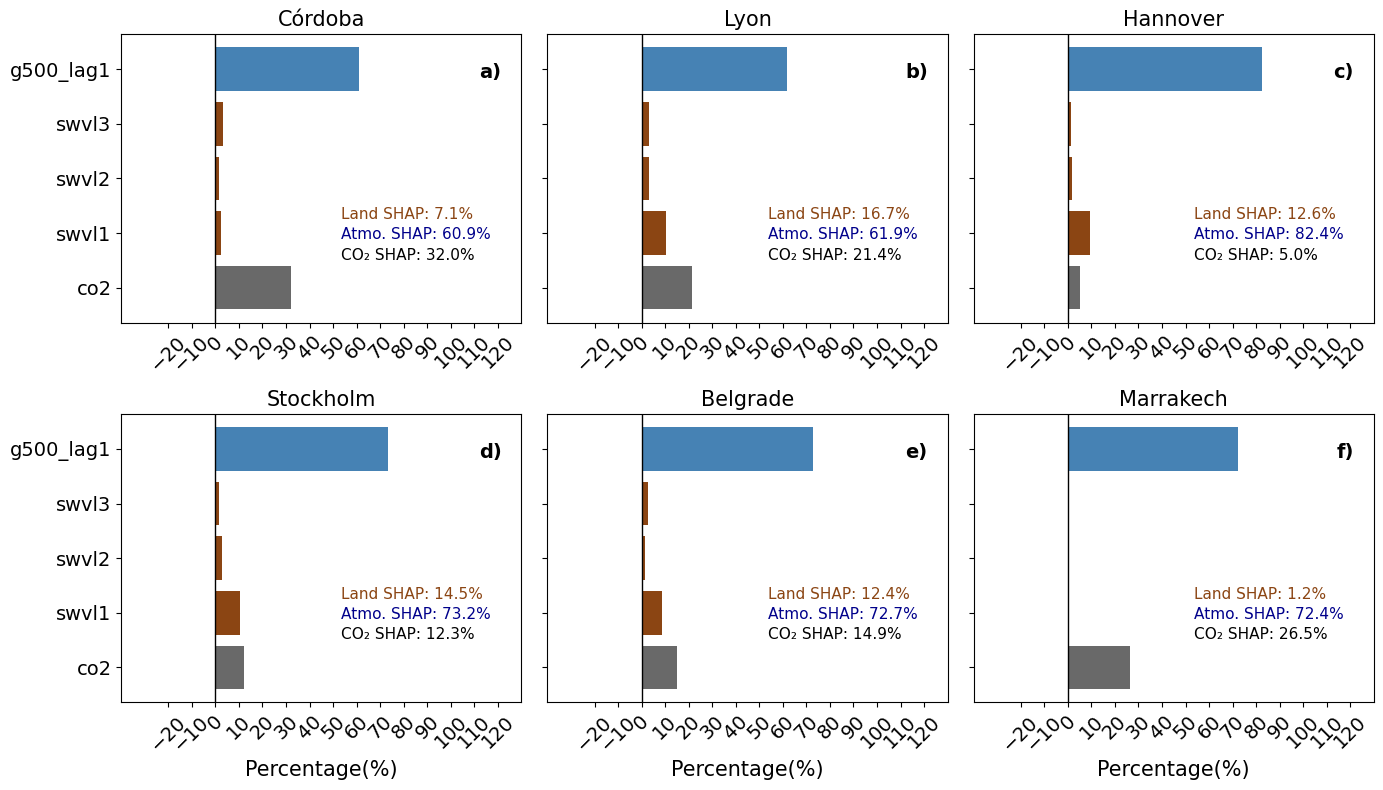

In [9]:
def draw_colored_text_block(ax, x, y, items):
    for i, (name, value, color) in enumerate(items):
        ax.text(x, y - i*0.07, f"{name}: {value:.1f}%", transform=ax.transAxes,
                fontsize=11, color=color, verticalalignment='top')


atmo_color = 'steelblue' 
land_color = 'saddlebrown'    
co2_color = 'dimgray'    

sites = ['cordoba','lyon','hannover','stockholm','belgrado','marrakech']
#sites = ['cordoba','lyon','hannover','stockholm','belgrado']

# Confusion Matrix plot ------------------------------------------------------------------------------------------------------

sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade', 'Marrakech']
#sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade']

# -----------------------------------------

_DATALOADERS_CONF = dict(
        batch_size= 32,
        drop_last= False,
        shuffle = True,
    )
    
_DATALOADERS_TEST_CONF = dict(
        batch_size= 32,
        drop_last= False,
        shuffle = False,
    ) 
    
HYPMS = dict(
    epochs= 75,
    lr= 1e-4,
    w_decay= 0.01,
)


#File paths ERA5 data 

file_g500 = "/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/g500_1x1_lagged_standarized_anomalies.nc"
file_g200 = "/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/g200_1x1_lagged_standarized_anomalies.nc"
file_psl = "/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/psl_1x1_lagged_standarized_anomalies.nc"

file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"


# Train features 

start_date = "1950-01-01"

# =====================================================================================
# Percentile Defition 
percentile = '90p'
using_spei = False
scales_spei = ['30','90']
spei_spi = 'spei'
spei_spi_variable_mapping = {
    'spei': [f'spei_hg_{scale_spei}' for scale_spei in scales_spei],
    'spi': [f'spi_{scale_spei}' for scale_spei in scales_spei]
    }

spei_variables = spei_spi_variable_mapping[spei_spi] # Variable name in the dataset for SPEI
distribution = 'gamma'  # 'GEV' or 'gamma'

# =====================================================================================


variables_era5 = ['g500']
variables_era5land = ['swvl1', 'swvl2', 'swvl3']


if using_spei:

    _ERA5LAND_TRAIN_DATASET_CONF = dict(
        start_date= start_date,
        end_date= "2013-12-31",
        months = [6,7,8],   
    )

    _ERA5LAND_TEST_DATASET_CONF = dict(
        start_date= "2014-01-01",
        end_date= "2023-12-31",
        months = [6,7,8],
        )

else:

    _ERA5LAND_TRAIN_DATASET_CONF = dict(
        start_date= start_date,
        end_date= "2013-12-31",
        months = [6,7,8],
        variables = variables_era5land
        )

    _ERA5LAND_TEST_DATASET_CONF = dict(
        start_date= "2014-01-01",
        end_date= "2023-12-31",
        months = [6,7,8],
        variables = variables_era5land
        )

_ERA5_TRAIN_DATASET_CONF = dict(
start_date= start_date,
end_date= "2013-12-31",
months = [6,7,8],
start_lag = 1,
lags_era5 = 1,
variables = variables_era5
    )

_ERA5_TEST_DATASET_CONF = dict(
start_date= "2014-01-01",
end_date= "2023-12-31",
months = [6,7,8],
start_lag = 1,
lags_era5 = 1,
variables = variables_era5      
    )

number_lags = _ERA5_TEST_DATASET_CONF['variables']



# Combined Dataset and Dataloader 

batch_size = _DATALOADERS_CONF['batch_size'] # batch size for dataloaders both datasets

fig_bar,axes_bar = plt.subplots(2,3,figsize=(14,8), sharex='col', sharey='row')
axes_bar = axes_bar.flatten()

count_plot = 0

for s,site in enumerate(sites): 

    print(f"doing site: {site}")
    
    #if site == 'belgrado': # Special case Belgrado to capture correctly the trend, discarding special case 1950 and 1952, which have a high extreme count. 
    #        start_date = "1953-01-01"
    #else:
    start_date = "1950-01-01"
    
    file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"


    if spei_spi == 'spi':
        files_spei =[f"/gpfs/projects/bsc32/bsc167965/observational_TX/{distribution}_{spei_spi}_tasmax_{site}_{scale_spei}_daily.nc"
                    for scale_spei in scales_spei] # For testing with 1 month scale
    elif spei_spi == 'spei':
        files_spei = [f"/gpfs/projects/bsc32/bsc167965/observational_TX/{distribution}_daily_{spei_spi}{scale_spei}_tasmax_{site}_hg.nc"
                        for scale_spei in scales_spei]

    
    if using_spei:
        train_dataset = SPEI_extremes_location_dataset(file_path=f"/gpfs/scratch/bsc32/bsc167965/data/era5_land/obs_lagged_anomalies_and_event_detection/obs_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", file_CO2=file_CO2 , files_spei = files_spei, **_ERA5LAND_TRAIN_DATASET_CONF, spei_variables = spei_variables, num_lags=7)
        test_dataset = SPEI_extremes_location_dataset(file_path=f"/gpfs/scratch/bsc32/bsc167965/data/era5_land/obs_lagged_anomalies_and_event_detection/obs_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", file_CO2=file_CO2 , files_spei = files_spei, **_ERA5LAND_TEST_DATASET_CONF, spei_variables = spei_variables, num_lags=7)
    
    else:
        train_dataset = machine_learning.LocalScale_Dataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/data/era5_land/lagged_anomalies_and_event_detection/{percentile}_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", file_CO2=file_CO2 , **_ERA5LAND_TRAIN_DATASET_CONF)
        test_dataset = machine_learning.LocalScale_Dataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/data/era5_land/lagged_anomalies_and_event_detection/{percentile}_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", file_CO2=file_CO2 , **_ERA5LAND_TEST_DATASET_CONF)

    
    train_features_era5 = machine_learning.LargeScale_Dataset_extremes(file_g500,file_g200,file_psl, **_ERA5_TRAIN_DATASET_CONF) # shape: features, time, lat, lon 
    test_features_era5 = machine_learning.LargeScale_Dataset_extremes(file_g500,file_g200,file_psl, **_ERA5_TEST_DATASET_CONF)
    

    combined_train_dataset  = machine_learning.CombinedDataset(train_dataset,train_features_era5,variables=variables_era5)
    combined_test_dataset = machine_learning.CombinedDataset(test_dataset,test_features_era5,variables=variables_era5)
          
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    device = torch.device("cpu")
    
    # Explainer data for SHAP 
    
    explainer_indices = np.arange(0,len(combined_test_dataset),1)
    
    explain_nn = []
    explain_cnn = []
    
    for idx in explainer_indices:
        nn_input, cnn_input, labels = combined_test_dataset[idx]  # Adjust based on your dataset structure
        explain_nn.append(nn_input)
        explain_cnn.append(cnn_input)
    
    explain_nn = torch.stack(explain_nn,dim=0).to(device)
    explain_cnn = torch.stack(explain_cnn,dim=0).to(device)
    
    explain_data = [explain_nn, explain_cnn]
    
    
    # Load computed SHAP


    main_path_res = '/home/bsc/bsc167965/TFM/ML/dictionaries_evaluation/'
    main_path_shap = '/gpfs/projects/bsc32/bsc167965/SHAP_values_Gradient/def_ensamble/'

    if using_spei:
        with open(os.path.join(main_path_res, f'1lag_{distribution}_daily_{spei_spi}_{percentile}_results_data_{site}.pkl'), 'rb') as f:
            dict_results = pickle.load(f)
        with open(os.path.join(main_path_shap, f'1lag_{distribution}_daily_{spei_spi}_{percentile}_SHAP_results_{site}.pkl'), 'rb') as f:
            loaded_shap_dict = pickle.load(f)

    else:
        #with open(os.path.join(main_path_res, f'{variables_era5[0]}_swvl1_{percentile}_results_data_{site}.pkl'), 'rb') as f:
        with open(os.path.join(main_path_res, f'g500_1lag_{percentile}_results_data_{site}.pkl'), 'rb') as f:

            dict_results = pickle.load(f)
        #with open(os.path.join(main_path_shap, f'{variables_era5[0]}_swvl1_{percentile}_SHAP_results_{site}.pkl'), 'rb') as f:
        with open(os.path.join(main_path_shap, f'g500_1lag_{percentile}_SHAP_results_{site}.pkl'), 'rb') as f:

            loaded_shap_dict = pickle.load(f)
    


    out_probabilities = dict_results['out_probs_sites']   

    y_true,y_pred = dict_results['y_true_pred_pairs']
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
        
    # Filter the predictions based on probabilities 
        
        
    mask = np.zeros_like(out_probabilities, dtype=bool)
    
    for i in range(out_probabilities.shape[1]):
        threshold = np.percentile(out_probabilities[:, i], 100 - 25)
    
        mask[:, i] = out_probabilities[:, i] >= threshold
    
    mask_def = mask[:,0] | mask[:,1] #True if either class 0 or 1 correspond to the top % confidence 

    mask_def_extreme = mask_def & (y_pred == 1)

    # Load SHAP values 

    shap_values_nn_raw = loaded_shap_dict['nn_mean']
    shap_values_cnn_raw = loaded_shap_dict['cnn_mean']

    # Filter shap values with mask 

    shap_values_nn_filtered = shap_values_nn_raw[mask_def_extreme]
    shap_values_cnn_filtered = shap_values_cnn_raw[mask_def_extreme]

    # Get names features and Explanation for the SHAP plot 

    explain_nn_np = explain_nn.cpu().numpy()
    
    nn_feature_names = test_dataset.all_features
    cnn_feature_names = test_features_era5.all_features
    all_names = nn_feature_names + cnn_feature_names
    
    cleaned_names = [
    name.replace("_anomalies", "").replace("lagged_era5", "")
    if "lagged_era5" in name else name.replace("_anomalies", "")
    for name in all_names
    ]

    # Assign colors per feature group
    color_mapping = {}
    circulation_features = ['g500']
    #circulation_features = ['g500']

    land_features = ['swvl1', 'swvl2', 'swvl3','spei','spi']
    co2_feature = ['co2']  # assuming the CO2 feature is named "co2"
    
    for name in cleaned_names:
        lname = name.lower()
        if any(circ in lname for circ in circulation_features):
            color_mapping[name] = atmo_color
        elif any(swvl in lname for swvl in land_features):
            color_mapping[name] = land_color
        elif 'co2' in lname:
            color_mapping[name] = co2_color

    
    # Convert to shap.Explanation object
    expl_nn = shap.Explanation(
        values=shap_values_nn_filtered,
        data=explain_nn.cpu().numpy()[mask_def_extreme],  # or .detach().cpu().numpy() if needed
        feature_names=nn_feature_names
    )

    shap_values_cnn_sum_spatial = np.sum(shap_values_cnn_filtered,axis=(2,3))

    all_shap_values = np.concatenate([shap_values_nn_filtered,shap_values_cnn_sum_spatial],axis=1)

    abs_shap = np.abs(all_shap_values)
    
    mean_abs_shap = np.mean(all_shap_values, axis=0)

    total_mean_shap = np.sum(mean_abs_shap[:],axis=0)

    if using_spei:
        land_SHAP = np.sum(mean_abs_shap[1:3]) / total_mean_shap * 100
        atmosphere_SHAP = np.sum(mean_abs_shap[3:]) / total_mean_shap * 100

    else:
        land_SHAP = np.sum(mean_abs_shap[1:4]) / total_mean_shap * 100
        atmosphere_SHAP = np.sum(mean_abs_shap[4:]) / total_mean_shap * 100

    
    co2_SHAP = np.sum(mean_abs_shap[:1]) / total_mean_shap * 100

    
    axes_bar[count_plot].set_xticks(np.arange(-20, 130, 10))
    bar_colors = [color_mapping[name] for name in cleaned_names]
    axes_bar[count_plot].barh(cleaned_names, mean_abs_shap / total_mean_shap * 100, color=bar_colors)  
    axes_bar[count_plot].axvline(x=0, color='black', linewidth=1)  # <-- vertical line at 0
    axes_bar[count_plot].set_xlim(-40,130)
    axes_bar[count_plot].set_title(f"{sites_title[s]}",fontsize=15)
    axes_bar[count_plot].text(0.95, 0.9, f'{chr(97+count_plot)})',  # 97 is ASCII for 'a'
                            transform=axes_bar[count_plot].transAxes,
                            fontsize=14,
                            fontweight='bold',
                            va='top',
                            ha='right')
    summary_items = [
        ("Land SHAP", land_SHAP, 'saddlebrown'),
        ("Atmo. SHAP", atmosphere_SHAP, 'darkblue'),
        ("CO₂ SHAP", co2_SHAP, 'black')
    ]

    draw_colored_text_block(axes_bar[count_plot], 0.55, 0.40, summary_items)

    axes_bar[count_plot].tick_params(axis='y', labelsize=14) 
    axes_bar[count_plot].tick_params(axis='x', labelsize=14,rotation=45) 
    axes_bar[count_plot].xaxis.set_ticks_position('bottom')



    count_plot += 1
    print(f"Finished site {site}")



for m in range(3,6):
    axes_bar[m].set_xlabel("Percentage(%)",fontsize=15)

if using_spei and len(sites) == 5:
    fig_bar.delaxes(axes_bar[-1])  # deletes the bottom right subplot

#fig_bar.suptitle("Contribution of Mean |SHAP value| CombinedModel (20 members)",fontsize=15)
fig_bar.tight_layout()



## Beeswarm SHAP plot using Matplotlib

doing site: cordoba
1
doing site: lyon
1
doing site: hannover
1
doing site: stockholm
1
doing site: belgrado
1


/scratch/tmp/ipykernel_1130103/402972964.py:311: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(right=0.85)


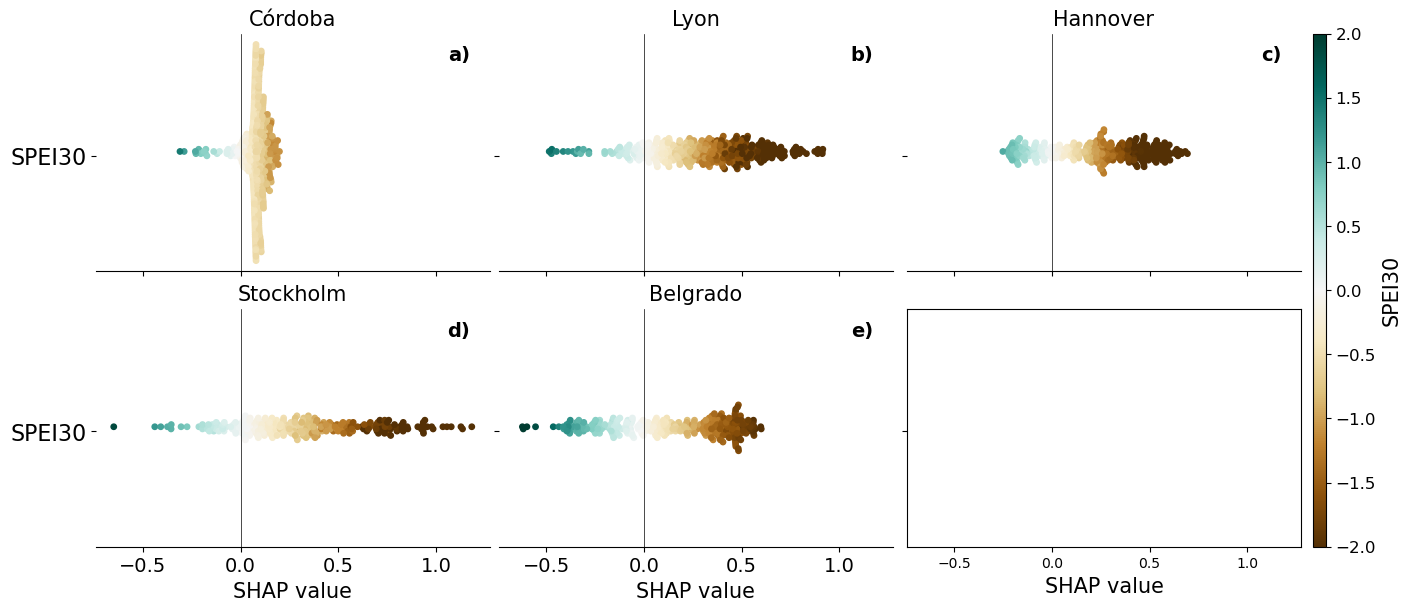

In [11]:
import matplotlib.pyplot as plt
import shap
import pickle
import numpy as np
from io import BytesIO
from PIL import Image
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import rankdata

import shap
shap_colors = shap.plots.colors.red_blue

shap_color_func = shap.plots.colors.red_blue  # this is a function
color_vals = np.linspace(0, 1, 256)           # 256 gradient steps
rgb_colors = [shap_color_func(v) for v in color_vals]  # sample into RGB

shap_colormap = LinearSegmentedColormap.from_list(
    "shap_red_blue", 
    rgb_colors
)

soil_moisture_colors = LinearSegmentedColormap.from_list(
    "soil_moisture_brown_green",
    ["saddlebrown", "wheat", "yellowgreen", "forestgreen"],
    N=256
)

# ===============================================================
# Functions 
# ===============================================================

def beeswarm_y(vals, gap=0.02):
    """
    Generates SHAP-like vertical jittering to separate overlapping SHAP values.
    Now with centered bidirectional offsets (up/down) to avoid stacking only above.
    """
    from collections import defaultdict

    sorted_idx = np.argsort(vals)
    sorted_vals = vals[sorted_idx]

    y_positions = np.zeros(len(vals))
    layers = defaultdict(list)

    for idx, val in zip(sorted_idx, sorted_vals):
        for layer_num in range(100):  
            offset = (layer_num + 1) // 2 * (-1)**layer_num 
            layer = layers[offset]
            if all(abs(val - v) > gap for v in layer):
                layer.append(val)
                y_positions[idx] = offset
                break

    # Scale spacing for aesthetics
    y_positions = y_positions * 0.25
    return y_positions

def custom_summary_plot(ax, shap_values, features, feature_names, cmap=cm.coolwarm, dot_size=15,feature_spacing=1.,vmin=None,vmax=None):
    
    try:
        num_features = shap_values.shape[1]
    except IndexError:
        num_features = 1
    print(num_features)

    for i in range(num_features):
        if num_features !=1:
            vals = shap_values[:, i]
            color_vals = features[:, i]
        else:
            vals = shap_values.ravel()
            color_vals = features.ravel()
    
        y_offsets = beeswarm_y(vals) 
            
        y_positions = i*feature_spacing + y_offsets if num_features > 1 else 0.5 + y_offsets
        
        ax.scatter(vals, y_positions,
                   c=color_vals, cmap=cmap,
                   s=dot_size, alpha=1, edgecolors=None, vmin=vmin, vmax=vmax)

    assert len(vals) == len(color_vals), "SHAP values and features must have same length"

    ax.set_yticks(range(num_features))
    if num_features == 1:
        ax.set_yticklabels([feature_names], fontsize=16)
    else:
        ytick_positions = [i * feature_spacing for i in range(num_features)]
        ax.set_yticks(ytick_positions)
        ax.set_yticklabels(feature_names, fontsize=16)
    ax.tick_params(axis='x', labelsize=14)
    

# =====================================================================================
# Percentile Defition 
percentile = '90p'
using_spei = False
scale_spei = '30'
spei_spi = 'spei'
spei_spi_variable_mapping = {'spei': f'spei_hg_{scale_spei}', 'spi': f'spi_{scale_spei}'}
spei_variable = spei_spi_variable_mapping[spei_spi] # Variable name in the dataset for SPEI

# =====================================================================================

file_g500 = "/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/g500_1x1_lagged_standarized_anomalies.nc"
file_g200 = "/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/g200_1x1_lagged_standarized_anomalies.nc"
file_psl = "/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/psl_1x1_lagged_standarized_anomalies.nc"

file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"

start_date = '1950-01-01'

number_lags = 3

if using_spei:

    _ERA5LAND_TRAIN_DATASET_CONF = dict(
        start_date= start_date,
        end_date= "2013-12-31",
        months = [6,7,8],   
    )

    _ERA5LAND_TEST_DATASET_CONF = dict(
        start_date= "2014-01-01",
        end_date= "2023-12-31",
        months = [6,7,8],
        )

else:
    _ERA5LAND_TRAIN_DATASET_CONF = dict(
        start_date= start_date,
        end_date= "2013-12-31",
        months = [6,7,8],
        variables = ['swvl1','swvl2','swvl3']
            )

    _ERA5LAND_TEST_DATASET_CONF = dict(
    start_date= "2014-01-01",
    end_date= "2023-12-31",
    months = [6,7,8],
    variables = ['swvl1','swvl2','swvl3']
        )

_ERA5_TRAIN_DATASET_CONF = dict(
start_date= start_date,
end_date= "2013-12-31",
months = [6,7,8],
start_lag = 1,
lags_era5 = 1,
variables = ['g500','g200','psl']
    )

_ERA5_TEST_DATASET_CONF = dict(
start_date= "2014-01-01",
end_date= "2023-12-31",
months = [6,7,8],
start_lag = 1,
lags_era5 = 1,
variables = ['g500','g200','psl']       
    )


fig, axs = plt.subplots(2, 3, figsize=(14, 6), sharex=True, sharey=True,constrained_layout=True) # sharex and sharey
axs = axs.flatten()

sites = ['cordoba','lyon','hannover' ,'stockholm','belgrado','marrakech']
sites = ['cordoba','lyon','hannover' ,'stockholm','belgrado']

sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrado', 'Marrakech' ]
sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrado' ]

v_min = 0 
v_max = 0

for count_plot, site in enumerate(sites):

    print(f"doing site: {site}")

    file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"

    if using_spei:
        if spei_spi == 'spei':
            file_spei = f"/gpfs/projects/bsc32/bsc167965/observational_TX/GEV_daily_spei{scale_spei}_tasmax_{site}_hg.nc"
        elif spei_spi == 'spi': 
            file_spei =f"/gpfs/projects/bsc32/bsc167965/observational_TX/{spei_spi}_tasmax_{site}_{scale_spei}_daily.nc" # For testing with 1 month scale

        train_dataset = SPEI_extremes_location_dataset(file_path=f"/gpfs/scratch/bsc32/bsc167965/data/era5_land/obs_lagged_anomalies_and_event_detection/obs_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", file_CO2=file_CO2 , file_spei = file_spei, **_ERA5LAND_TRAIN_DATASET_CONF, spei_variable = spei_variable, num_lags=7 )
        test_dataset = SPEI_extremes_location_dataset(file_path=f"/gpfs/scratch/bsc32/bsc167965/data/era5_land/obs_lagged_anomalies_and_event_detection/obs_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", file_CO2=file_CO2 , file_spei = file_spei, **_ERA5LAND_TEST_DATASET_CONF, spei_variable = spei_variable, num_lags=7 )
    else:
        train_dataset = machine_learning.LocalScale_Dataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/data/era5_land/lagged_anomalies_and_event_detection/{percentile}_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", file_CO2=file_CO2 , **_ERA5LAND_TRAIN_DATASET_CONF)
        test_dataset = machine_learning.LocalScale_Dataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/data/era5_land/lagged_anomalies_and_event_detection/{percentile}_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", file_CO2=file_CO2 , **_ERA5LAND_TEST_DATASET_CONF)

        
    
    train_features_era5 = machine_learning.LargeScale_Dataset_extremes(file_g500,file_g200,file_psl, **_ERA5_TRAIN_DATASET_CONF) # shape: features, time, lat, lon 
    test_features_era5 = machine_learning.LargeScale_Dataset_extremes(file_g500,file_g200,file_psl, **_ERA5_TEST_DATASET_CONF)

    
    combined_train_dataset  = machine_learning.CombinedDataset(train_dataset,train_features_era5, variables=variables_era5)
    combined_test_dataset = machine_learning.CombinedDataset(test_dataset,test_features_era5, variables=variables_era5)
        
 

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    device = torch.device("cpu")
    
    # Explainer data for SHAP 
    
    explainer_indices = np.arange(0,len(combined_test_dataset),1)
    
    explain_nn = []
    explain_cnn = []
    
    for idx in explainer_indices:
        nn_input, cnn_input, labels = combined_test_dataset[idx] # Adjust based on your dataset structure
        explain_nn.append(nn_input)
        explain_cnn.append(cnn_input)
    
    explain_nn = torch.stack(explain_nn,dim=0).to(device)
    explain_cnn = torch.stack(explain_cnn,dim=0).to(device)
    
    explain_data = [explain_nn, explain_cnn]
    
    main_path_res = '/home/bsc/bsc167965/TFM/ML/dictionaries_evaluation/'
    main_path_shap = '/gpfs/projects/bsc32/bsc167965/SHAP_values_Gradient/def_ensamble/'

    if using_spei:
        with open(os.path.join(main_path_res, f'1lag_GEV_daily_{spei_spi}{scale_spei}_{percentile}_results_data_{site}.pkl'), 'rb') as f:
            dict_results = pickle.load(f)
        with open(os.path.join(main_path_shap, f'1lag_GEV_daily_{spei_spi}{scale_spei}_{percentile}_SHAP_results_{site}.pkl'), 'rb') as f:
            loaded_shap_dict = pickle.load(f)

    else:
        with open(os.path.join(main_path_res, f'nolags_{percentile}_results_data_{site}.pkl'), 'rb') as f:
            dict_results = pickle.load(f)
        with open(os.path.join(main_path_shap, f'nolags_{percentile}_SHAP_results_{site}.pkl'), 'rb') as f:
            loaded_shap_dict = pickle.load(f)
    
    out_probabilities = dict_results['out_probs_sites']
    y_true,y_pred = dict_results['y_true_pred_pairs']
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = np.zeros_like(out_probabilities, dtype=bool)
    for i in range(out_probabilities.shape[1]):
        threshold = np.percentile(out_probabilities[:, i], 0.75)
        mask[:, i] = out_probabilities[:, i] >= threshold
    mask_def = mask[:, 0] | mask[:, 1]
    mask_def_extreme = mask_def & (y_pred == 1)
    shap_values_nn_raw = loaded_shap_dict['nn_mean']
    shap_values_nn_filtered = shap_values_nn_raw[mask_def_extreme]
    input_data = explain_nn.cpu().numpy()[mask_def_extreme]
    nn_feature_names = train_dataset.all_features

    cleaned_names = [
        name.replace("_anomalies", "").replace("lagged_era5", "")
        if "lagged_era5" in name else name.replace("_anomalies", "").replace("_spei_hg_30", "SPEI30")
        for name in nn_feature_names ]
    
    expl_nn = shap.Explanation(
        values=shap_values_nn_filtered[:,1],
        data=input_data[:,1],
        feature_names=cleaned_names[1])
    

    v_min_temp = np.min(input_data[:,1])
    v_max_temp = np.max(input_data[:,1])
    
    cleaned_names = ["co2","SPEI30",]

    ax = axs[count_plot]
    custom_summary_plot(ax, shap_values_nn_filtered[:,1], input_data[:,1], cleaned_names[1],cmap="BrBG", feature_spacing=0., vmin=-2, vmax=2)
    ax.set_title(sites_title[count_plot], fontsize=15)
    ax.axvline(x=0, color='black', linewidth=0.5, linestyle='-')
    ax.text(0.95, 0.95, f'{chr(97+count_plot)})',  # 97 is ASCII for 'a'
                            transform=ax.transAxes,
                            fontsize=14,
                            fontweight='bold',
                            va='top',
                            ha='right')
    #ax.tick_params(axis='both', which='major', labelsize=18) # Change tick font s
    #ax.set_ylabel()

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

    if v_min_temp < v_min:
        v_min = v_min_temp
    elif v_max_temp > v_max: 
        v_max = v_max_temp

from mpl_toolkits.axes_grid1 import make_axes_locatable

for i in range(3,6):
    axs[i].set_xlabel("SHAP value", fontsize=15)

norm = plt.Normalize(vmin=-2, vmax=2)
sm = plt.cm.ScalarMappable(cmap='BrBG', norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.02, pad=0.01, label='Anomaly', aspect=40)
cbar.set_label(r'SPEI30', fontsize=15)

cbar.ax.tick_params(labelsize=12)

if using_spei and len(sites) == 5:
    fig.delaxes(axs[-1])  # deletes the bottom right subplot


#plt.suptitle("SHAP values swvl across samples CombinedModel",fontsize=15)
plt.subplots_adjust(right=0.85)
#plt.suptitle("soil moisture (swvl) levels feature importance", fontsize=20)
plt.show()


